## SVR — VARIANTE HORIZONTE 21 DÍAS (Opción 3: intento de mejora)

Misma metodología que `05_svr.ipynb`, pero entrenando sobre el target de 21 días en vez de 5, para ver si un horizonte más largo captura más señal real.

Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier


In [2]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "svr_h21"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_HORIZON = 21
FEATURES_FILE = DATA_DIR / f"features_dataset_h{TARGET_HORIZON}.csv"

TRAIN_TEST_SPLIT_DATE = "2024-01-01"

FEATURE_COLS = [
    "return_1d", "return_5d", "return_10d", "return_21d", "return_63d",
    "sma_10", "sma_20", "sma_50",
    "ema_10", "ema_20", "ema_50",
    "vol_10", "vol_20", "vol_50",
    "rsi_14", "macd", "macd_signal",
    "bb_high", "bb_low"
]

TARGET_COL = f"target_return_{TARGET_HORIZON}d"

benchmark = "^GSPC"
MAX_WEIGHT = 0.15

print("Target:", TARGET_COL)
print("Directorio de resultados:", RESULTS_DIR)


Target: target_return_21d
Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\svr_h21


## Carga del dataset (horizonte 21 días, generado en 03b_feature_engineering_h21.ipynb)

In [3]:
dataset = pd.read_csv(FEATURES_FILE, parse_dates=["Date"])
tickers = sorted(dataset["ticker"].unique())

print("Activos:", len(tickers))
dataset.head()


Activos: 21


,Date,ticker,return_5d,return_10d,return_21d,return_63d,return_1d,sma_10,sma_20,sma_50,...,ema_50,vol_10,vol_20,vol_50,rsi_14,macd,macd_signal,bb_high,bb_low,target_return_21d
0,2018-04-05,AAPL,0.037962,0.008933,-0.021905,0.007400,0.006934,39.600020,40.618843,40.054935,...,40.323861,0.350188,0.277843,0.295302,51.668555,-0.258639,-0.196717,43.021589,38.216096,0.063831
1,2018-04-06,AAPL,0.003577,-0.002783,-0.037993,-0.022906,-0.025578,39.588999,40.518473,40.030863,...,40.291025,0.368379,0.287977,0.298714,44.927547,-0.282602,-0.213894,42.934290,38.102656,0.099655
2,2018-04-09,AAPL,0.020219,0.030981,-0.038940,-0.024324,0.009918,39.708834,40.402041,40.029150,...,40.274834,0.347060,0.282557,0.296884,47.703722,-0.266916,-0.224499,42.702878,38.101203,0.094090
3,2018-04-10,AAPL,0.028862,0.002779,-0.037393,-0.002258,0.018818,39.720092,40.302726,40.040577,...,40.288706,0.264977,0.289640,0.299806,52.631237,-0.191721,-0.217943,42.372833,38.232619,0.081443
4,2018-04-11,AAPL,0.004837,0.024356,-0.051067,-0.006808,-0.004675,39.816242,40.214435,40.064789,...,40.294586,0.225191,0.288492,0.296126,51.313309,-0.145775,-0.203510,42.094472,38.334398,0.102064


## Split train/test

In [4]:
train_full = dataset[dataset["Date"] < TRAIN_TEST_SPLIT_DATE]
test_full = dataset[dataset["Date"] >= TRAIN_TEST_SPLIT_DATE]

print("Filas train:", train_full.shape[0], "| Filas test:", test_full.shape[0])


Filas train: 30345 | Filas test: 13503


## Entrenamiento: un SVR por activo (mismo procedimiento que en 05_svr.ipynb)

In [5]:
PARAM_GRID = {
    "C": [0.1, 1, 10],
    "epsilon": [0.001, 0.01, 0.1],
    "gamma": ["scale", "auto"]
}

tscv = TimeSeriesSplit(n_splits=5)

results = []
predictions = {}

for ticker in tickers:

    if ticker == benchmark:
        continue

    train_t = train_full[train_full["ticker"] == ticker]
    test_t = test_full[test_full["ticker"] == ticker]

    if len(train_t) < 100 or len(test_t) < 20:
        print(f"{ticker}: datos insuficientes, se omite")
        continue

    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(train_t[FEATURE_COLS])
    X_test = scaler_X.transform(test_t[FEATURE_COLS])

    scaler_y = StandardScaler()
    y_train = scaler_y.fit_transform(train_t[[TARGET_COL]]).ravel()
    y_test = test_t[TARGET_COL].values

    grid = GridSearchCV(
        SVR(kernel="rbf"),
        PARAM_GRID,
        cv=tscv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred_scaled = best_model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    predictions[ticker] = pd.DataFrame({
        "Date": test_t["Date"].values,
        "actual": y_test,
        "predicted": y_pred
    })

    results.append({
        "ticker": ticker,
        "best_C": grid.best_params_["C"],
        "best_epsilon": grid.best_params_["epsilon"],
        "best_gamma": grid.best_params_["gamma"],
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{ticker}: RMSE={rmse:.5f}  R2={r2:.4f}  params={grid.best_params_}")

results_df = pd.DataFrame(results).set_index("ticker")


AAPL: RMSE=0.07861  R2=-0.1923  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'auto'}
ADBE: RMSE=0.11013  R2=-0.1637  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
AMZN: RMSE=0.10599  R2=-0.5309  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale'}
CAT: RMSE=0.09508  R2=-0.0349  params={'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale'}
GOOGL: RMSE=0.09887  R2=-0.1755  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'auto'}
HD: RMSE=0.08300  R2=-0.6380  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
JNJ: RMSE=0.05653  R2=-0.0728  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'auto'}
JPM: RMSE=0.06477  R2=-0.1528  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'auto'}
KO: RMSE=0.05774  R2=-0.5746  params={'C': 0.1, 'epsilon': 0.01, 'gamma': 'auto'}
MA: RMSE=0.06762  R2=-0.7712  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale'}
META: RMSE=0.10736  R2=-0.0832  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
MSFT: RMSE=0.08801  R2=-0.1664  params={'C': 0.1, 'epsilon': 0.001, 'gamma'

## Comparación directa: R² a 5 días (Fase 6 original) vs. R² a 21 días

Este es el chequeo central de la Opción 3: si el horizonte de 21 días efectivamente captura más señal, deberíamos ver R² sistemáticamente menos negativos (o positivos) aquí que en el notebook original.

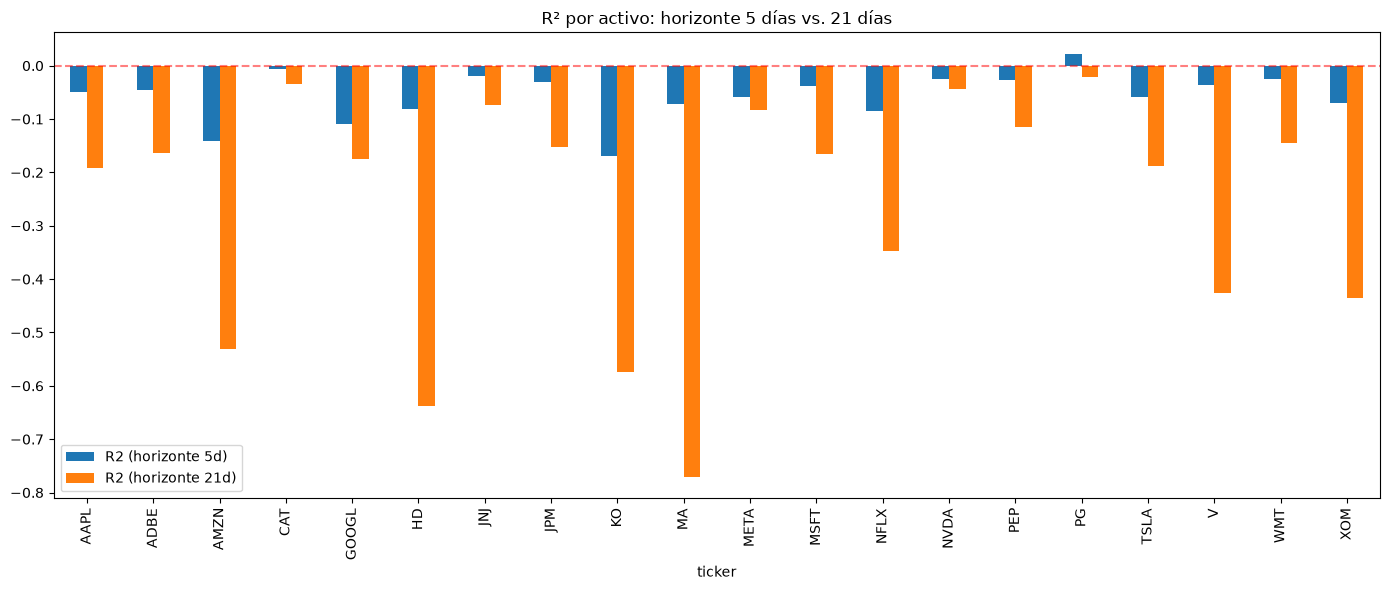

Promedio R2 a 5 días: -0.0563
Promedio R2 a 21 días: -0.2639


In [6]:
RESULTS_H5_FILE = PROJECT_ROOT / "results" / "svr" / "svr_performance_by_ticker.csv"

if RESULTS_H5_FILE.exists():
    results_h5 = pd.read_csv(RESULTS_H5_FILE, index_col="ticker")

    r2_comparison = pd.DataFrame({
        "R2 (horizonte 5d)": results_h5["R2"],
        "R2 (horizonte 21d)": results_df["R2"]
    }).dropna()

    r2_comparison.plot(kind="bar", figsize=(14, 6), title="R² por activo: horizonte 5 días vs. 21 días")
    plt.axhline(0, color="red", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "01_r2_comparacion_horizontes.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Promedio R2 a 5 días:", r2_comparison['R2 (horizonte 5d)'].mean().round(4))
    print("Promedio R2 a 21 días:", r2_comparison['R2 (horizonte 21d)'].mean().round(4))
else:
    print("No se encontró", RESULTS_H5_FILE, "— corre primero 05_svr.ipynb, o compara manualmente con results_df de abajo.")
    results_df.sort_values("R2", ascending=False).round(5)


## Vector mu_svr_h21 (si el resultado justifica seguir adelante)

Solo tiene sentido usar esto en Markowitz si el R² mejoró de forma real respecto al horizonte de 5 días — revisa la comparación de arriba antes de continuar.

In [7]:
PERIODS_PER_YEAR_H21 = 252 / TARGET_HORIZON

mu_svr_h21 = {}
for ticker, pred_df in predictions.items():
    mean_return = pred_df["predicted"].mean()
    mu_svr_h21[ticker] = (1 + mean_return) ** PERIODS_PER_YEAR_H21 - 1

mu_svr_h21 = pd.Series(mu_svr_h21, name="mu_svr_h21").sort_values(ascending=False)

mu_svr_h21


MA       0.832836
V        0.655279
META     0.568435
ADBE     0.506229
NVDA     0.400956
CAT      0.362417
MSFT     0.354612
PEP      0.266220
JPM      0.159983
WMT      0.064720
JNJ      0.049358
GOOGL    0.026177
AAPL    -0.088174
PG      -0.090299
KO      -0.167190
NFLX    -0.169331
XOM     -0.211833
TSLA    -0.245715
AMZN    -0.365586
HD      -0.417949
Name: mu_svr_h21, dtype: float64

## Markowitz con mu_svr_h21 (mismo procedimiento que en la Opción 1)

In [8]:
prices_for_mu = pd.read_csv(DATA_DIR / "adjusted_prices.csv", index_col=0, parse_dates=True)
asset_prices_svr_h21 = prices_for_mu.drop(columns=[benchmark])

S_shrink_h21 = CovarianceShrinkage(asset_prices_svr_h21).ledoit_wolf()

ef_svr_h21 = EfficientFrontier(mu_svr_h21, S_shrink_h21, weight_bounds=(0, MAX_WEIGHT))
raw_weights_h21 = ef_svr_h21.max_sharpe(risk_free_rate=0.02)
weights_svr_h21 = ef_svr_h21.clean_weights()

perf_svr_h21 = ef_svr_h21.portfolio_performance(verbose=True, risk_free_rate=0.02)

pd.Series(weights_svr_h21).sort_values(ascending=False)


Expected annual return: 49.8%
Annual volatility: 19.5%
Sharpe Ratio: 2.45


MA       0.15
V        0.15
META     0.15
ADBE     0.15
MSFT     0.15
JPM      0.15
CAT      0.10
NVDA     0.00
PEP      0.00
WMT      0.00
JNJ      0.00
GOOGL    0.00
AAPL     0.00
PG       0.00
KO       0.00
NFLX     0.00
XOM      0.00
TSLA     0.00
AMZN     0.00
HD       0.00
dtype: float64

## Guardar resultados

In [ ]:
results_df.to_csv(RESULTS_DIR / "svr_h21_performance_by_ticker.csv")
mu_svr_h21.to_csv(RESULTS_DIR / "mu_svr_h21.csv")
pd.Series(weights_svr_h21).to_csv(RESULTS_DIR / "weights_markowitz_svr_h21.csv")

print("Resultados guardados en:", RESULTS_DIR)


Resultados guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\svr_h21


: 